In [10]:
import os
import sys
import pandas as pd
import numpy as np

project_root = os.path.abspath("..")
sys.path.append(project_root)

from src.analysis_utils import (
    collect_eval_results,
    normalize_metric,
    build_top_configs,
    build_sample_dataset,
    plot_prompt_heatmap,
)

In [11]:
INPUT_PATH = "../data/processed/prompts.parquet"
OUTPUT_PATH = "../data/experts/prompts.parquet"
EVAL_RESULT_ROOT = "/mnt/public/code/hanyu/codes/SEAP/eval_out_transfer"
SAMPLES_PER_GROUP = 128
RANDOM_SEED = 42

In [12]:
df_eval = collect_eval_results(EVAL_RESULT_ROOT)
df_eval = normalize_metric(df_eval)

In [13]:
df_eval.head()

,Task,Version,Filter,Shot,Metric,Arrow,Value,Stderr,Display,Model,calib,prompt,method,strategy,ratio,Metric_for_use
0,arc_challenge,1.0,none,0,acc,↑,0.480375,0.014600,0.4804 ± 0.0146,Llama-2-13b-hf,arc_easy,cot,WIFV,logistic,0.2,acc
1,arc_challenge,1.0,none,0,acc,↑,0.476109,0.014595,0.4761 ± 0.0146,Llama-2-13b-hf,piqa,knowledge,WIFV,logistic,0.2,acc
2,arc_challenge,1.0,none,0,acc,↑,0.472696,0.014590,0.4727 ± 0.0146,Llama-2-13b-hf,arc_easy,zero_shot,WIFV,logistic,0.2,acc
3,arc_challenge,1.0,none,0,acc,↑,0.471843,0.014588,0.4718 ± 0.0146,Llama-2-13b-hf,arc_challenge,cot,WIFV,logistic,0.2,acc
4,arc_challenge,1.0,none,0,acc,↑,0.470137,0.014585,0.4701 ± 0.0146,Llama-2-13b-hf,openbookqa,cot,WIFV,logistic,0.2,acc


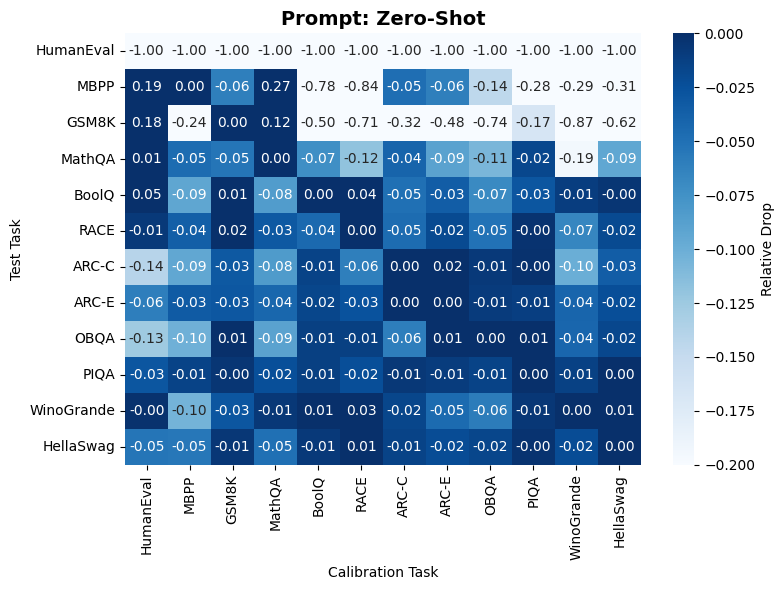

In [14]:
# 基于自身对角线（即 Task == calib）作为 baseline
plot_prompt_heatmap(df_eval, prompt_type="zero_shot", model_name="Llama-2-13b-hf", normalize_mode="self")

In [15]:
# ==== 主流程 ====
df_data = pd.read_parquet(INPUT_PATH)
df_data["task_type"] = df_data["task_type"].str.lower()

In [16]:
top5_config = build_top_configs(df_eval)
top5_config

,TaskGroup,calib,prompt,Value,Weight
0,code_gen,humaneval,knowledge,0.102000,0.213613
1,code_gen,mbpp,corpus,0.097000,0.203141
2,code_gen,humaneval,icl,0.094000,0.196859
3,code_gen,humaneval,corpus,0.093500,0.195812
4,code_gen,mbpp,cot,0.091000,0.190576
5,commonsense,hellaswag,knowledge,0.681348,0.201180
6,commonsense,winogrande,knowledge,0.678408,0.200312
7,commonsense,piqa,knowledge,0.676074,0.199623
8,commonsense,openbookqa,knowledge,0.675543,0.199466
9,commonsense,race,knowledge,0.675377,0.199417


In [17]:
final_dataset = build_sample_dataset(df_data, top5_config)

In [18]:
final_dataset

,task_type,task_format,question,label,gold,corpus,rationale,knowledge,split,prompt_zero_shot,prompt_cot,prompt_icl,prompt_icl_cot,prompt_experts
0,code_gen,generative,Implement the function `get_closest_vowel` as ...,,"\ndef get_closest_vowel(word):\n """"""You are...","\ndef get_closest_vowel(word):\n """"""You are...",Rationale:\nThe function `get_closest_vowel` a...,"```python\ndef get_closest_vowel(word):\n ""...",train,# Task:\nImplement the function `get_closest_v...,# Task:\nImplement the function `get_closest_v...,# Task:\nImplement the function `flip_case` as...,# Task:\nImplement the function `flip_case` as...,"```python\ndef get_closest_vowel(word):\n ""..."
1,code_gen,generative,Implement the function `string_xor` as specifi...,,from typing import List\n\n\ndef string_xor(a:...,from typing import List\n\n\ndef string_xor(a:...,Rationale:\nThe function `string_xor` takes tw...,```python\n# This function performs a binary X...,train,# Task:\nImplement the function `string_xor` a...,# Task:\nImplement the function `string_xor` a...,# Task:\nImplement the function `next_smallest...,# Task:\nImplement the function `next_smallest...,```python\n# This function performs a binary X...
2,code_gen,generative,Implement the function `sort_third` as specifi...,,"\n\ndef sort_third(l: list):\n """"""This func...","\n\ndef sort_third(l: list):\n """"""This func...",Rationale:\nThe function `sort_third` aims to ...,"```python\ndef sort_third(l: list):\n """"""Th...",train,# Task:\nImplement the function `sort_third` a...,# Task:\nImplement the function `sort_third` a...,# Task:\nImplement the function `add` as speci...,# Task:\nImplement the function `add` as speci...,"```python\ndef sort_third(l: list):\n """"""Th..."
3,code_gen,generative,Implement the function `largest_divisor` as sp...,,"\n\ndef largest_divisor(n: int) -> int:\n ""...","\n\ndef largest_divisor(n: int) -> int:\n ""...",Rationale:\nThe goal of the function `largest_...,```python\n# This function finds the largest d...,train,# Task:\nImplement the function `largest_divis...,# Task:\nImplement the function `largest_divis...,# Task:\nImplement the function `by_length` as...,# Task:\nImplement the function `by_length` as...,```python\n# This function finds the largest d...
4,code_gen,generative,Implement the function `max_element` as specif...,,"\n\ndef max_element(l: list):\n """"""Return m...","\n\ndef max_element(l: list):\n """"""Return m...",Rationale:\nThe function `max_element` is desi...,```python\n# This function finds and returns t...,train,# Task:\nImplement the function `max_element` ...,# Task:\nImplement the function `max_element` ...,# Task:\nImplement the function `simplify` as ...,# Task:\nImplement the function `simplify` as ...,```python\n# This function finds and returns t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639,math_reasoning,generative,"Question: When Betty makes cheesecake, she swe...",,"Betty used 2 cups of sugar in her cheesecake, ...","Question: When Betty makes cheesecake, she swe...",Rationale:\nTo determine the number of eggs Be...,To solve problems involving ratios and proport...,train,# Task:\nQuestion: When Betty makes cheesecake...,# Task:\nQuestion: When Betty makes cheesecake...,# Task:\nQuestion: Fiona completed 36 math que...,# Task:\nQuestion: Fiona completed 36 math que...,# Task:\nQuestion: When Betty makes cheesecake...
640,math_reasoning,generative,Question: It takes 20 minutes for John to go t...,,He spends 20/8=<<20/8=2.5>>2.5 minutes each ti...,Question: It takes 20 minutes for John to go t...,"Rationale:\nTo solve this problem, we first de...",To solve problems involving proportional relat...,train,# Task:\nQuestion: It takes 20 minutes for Joh...,# Task:\nQuestion: It takes 20 minutes for Joh...,# Task:\nQuestion: A single line is worth 1000...,# Task:\nQuestion: A single line is worth 1000...,# Task:\nQuestion: It takes 20 minutes for Joh...
641,math_reasoning,generative,Question: Diane bought

In [ ]:
# final_dataset.to_parquet("../data/experts/prompts.parquet", index=False)
# print("✅ Saved:", "../data/experts/prompts.parquet")

✅ Saved: ../data/experts/prompts.parquet


In [20]:
# output_path = "/mnt/public/code/hanyu/codes/SEAP/eval_summary.xlsx"
# df_all.to_excel(output_path, index=False)

# print(f"Saved: {output_path}")